# nteract Desktop Download Stats

Pulling release download counts from the GitHub API for [nteract/desktop](https://github.com/nteract/desktop).

In [14]:
# Fetch ALL releases from nteract/desktop (paginated)
releases = []
page = 1
while True:
    resp = requests.get(
        "https://api.github.com/repos/nteract/desktop/releases",
        params={"per_page": 100, "page": page},
    )
    resp.raise_for_status()
    data = resp.json()
    if not data:
        break
    releases.extend(data)
    page += 1

print(f"Found {len(releases)} releases")
print(f"Releases with assets: {sum(1 for r in releases if r.get('assets'))}")

Found 165 releases
Releases with assets: 165


In [15]:
# Refine platform detection to capture more assets
def classify_platform(name):
    nl = name.lower()
    if "darwin" in nl or nl.endswith(".dmg") or "mac" in nl:
        return "macOS"
    elif "win" in nl or nl.endswith(".exe") or nl.endswith(".msi"):
        return "Windows"
    elif (
        "linux" in nl
        or nl.endswith(".deb")
        or nl.endswith(".rpm")
        or nl.endswith(".appimage")
    ):
        return "Linux"
    elif nl.endswith(".whl") or nl.endswith(".tar.gz") and "nteract-" in nl:
        return "Python (pip)"
    elif nl == "latest.json":
        return "Auto-update manifest"
    else:
        return "Other"


df["platform"] = df["asset"].apply(classify_platform)

print("Downloads by platform:")
print(df.groupby("platform")["downloads"].sum().sort_values(ascending=False))
print(f"\nTotal: {df['downloads'].sum():,}")

Downloads by platform:
platform
macOS                   525
Linux                   271
Windows                 184
Auto-update manifest    139
Python (pip)              1
Name: downloads, dtype: int64

Total: 1,120


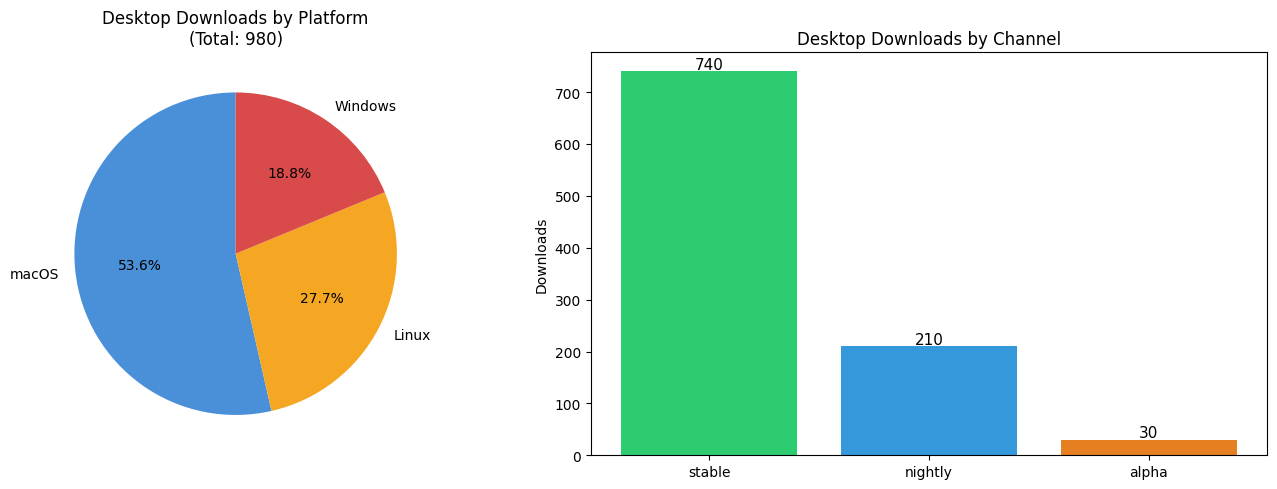

In [16]:
# Filter to actual desktop downloads (exclude manifests, python packages)
desktop_platforms = ["macOS", "Windows", "Linux"]
desktop_df = df[df["platform"].isin(desktop_platforms)]

# Downloads per release (stable only, aggregated)
stable = desktop_df[desktop_df["channel"] == "stable"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Pie chart: Downloads by platform ---
platform_totals = (
    desktop_df.groupby("platform")["downloads"].sum().sort_values(ascending=False)
)
colors = {"macOS": "#4A90D9", "Windows": "#D94A4A", "Linux": "#F5A623"}
axes[0].pie(
    platform_totals.values,
    labels=platform_totals.index,
    autopct="%1.1f%%",
    colors=[colors[p] for p in platform_totals.index],
    startangle=90,
)
axes[0].set_title(
    f"Desktop Downloads by Platform\n(Total: {desktop_df['downloads'].sum():,})"
)

# --- Bar chart: Downloads by channel ---
channel_totals = (
    desktop_df.groupby("channel")["downloads"].sum().sort_values(ascending=False)
)
bars = axes[1].bar(
    channel_totals.index, channel_totals.values, color=["#2ECC71", "#3498DB", "#E67E22"]
)
axes[1].set_title("Desktop Downloads by Channel")
axes[1].set_ylabel("Downloads")
for bar, val in zip(bars, channel_totals.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(val),
        ha="center",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

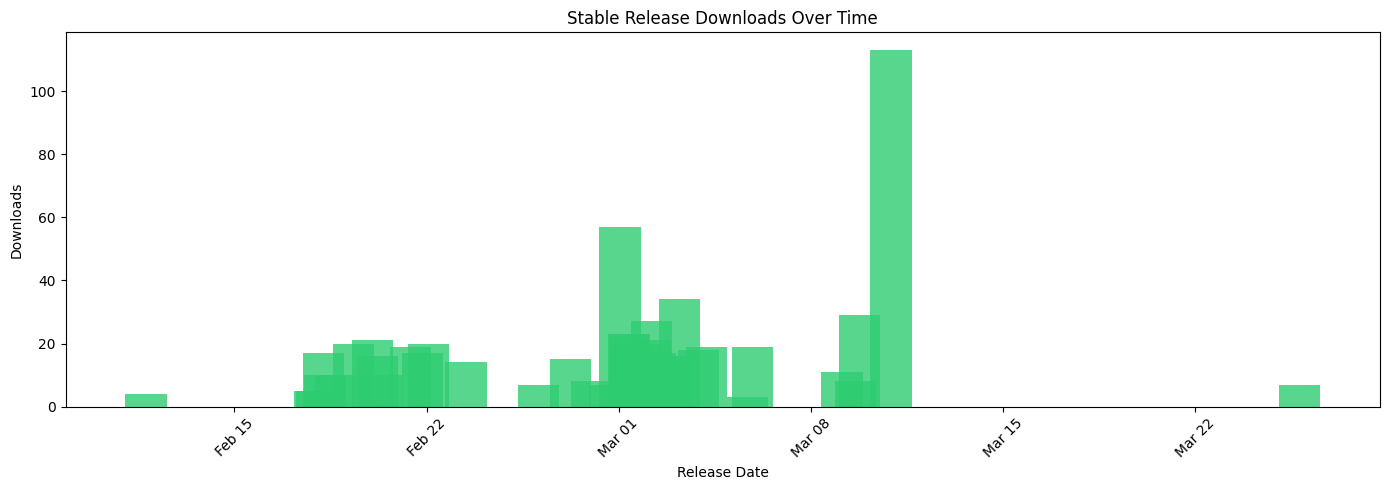


Top 10 stable releases by downloads:


,release,published,downloads
37,v1.4.1-stable.202603102148,2026-03-10 22:02:17+00:00,113
20,v1.3.0-dev.1-preview.b7ee30a,2026-03-01 01:07:54+00:00,57
29,v1.4.1-preview.202603030430,2026-03-03 05:03:30+00:00,34
36,v1.4.1-stable.202603091829,2026-03-09 18:43:13+00:00,29
23,v1.4.0-preview.ab57682,2026-03-02 04:35:55+00:00,27
13,v1.3.0-dev.1-preview.2a82c93,2026-03-01 08:27:31+00:00,23
19,v1.3.0-dev.1-preview.a551e6a,2026-03-01 09:47:14+00:00,23
24,v1.4.0-preview.d506532,2026-03-02 03:49:41+00:00,21
9,v1.2.0-preview.9e1c08e,2026-02-20 00:38:23+00:00,21
6,v1.2.0-preview.6a2ac9a,2026-02-19 07:49:54+00:00,20


In [17]:
# Downloads over time — aggregate by release date (stable releases)
stable_by_release = (
    stable.groupby(["release", "published"])["downloads"]
    .sum()
    .reset_index()
    .sort_values("published")
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    stable_by_release["published"],
    stable_by_release["downloads"],
    width=1.5,
    color="#2ECC71",
    alpha=0.8,
)
ax.set_title("Stable Release Downloads Over Time")
ax.set_xlabel("Release Date")
ax.set_ylabel("Downloads")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %d"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop 10 stable releases by downloads:")
stable_by_release.sort_values("downloads", ascending=False).head(10)[
    ["release", "published", "downloads"]
]

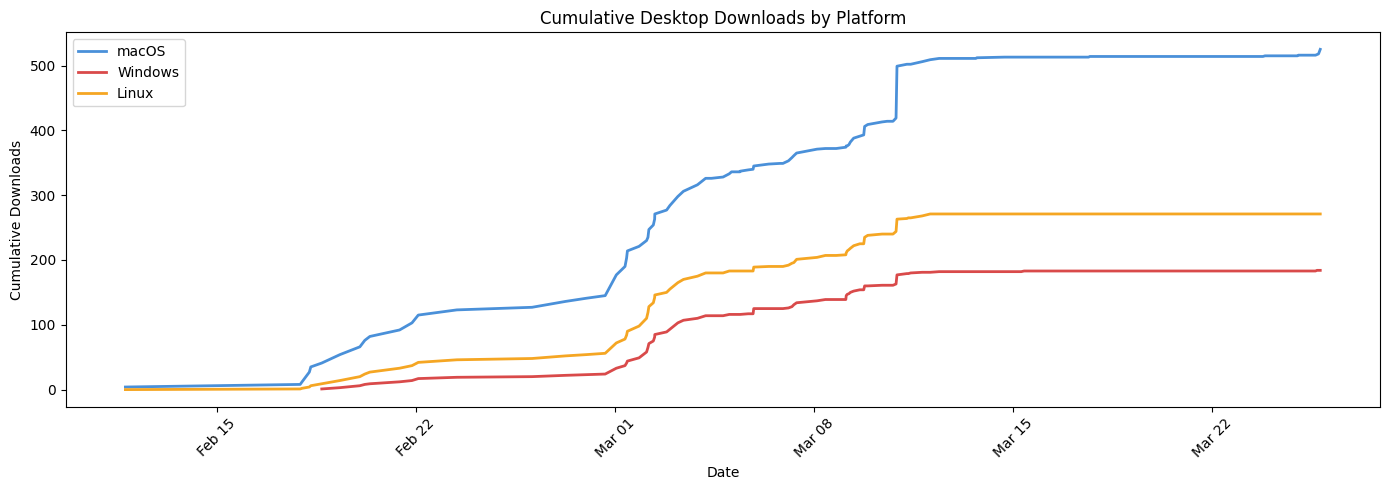

In [18]:
# Downloads by platform over time (cumulative)
desktop_df_sorted = desktop_df.sort_values("published")

fig, ax = plt.subplots(figsize=(14, 5))
for platform, color in [
    ("macOS", "#4A90D9"),
    ("Windows", "#D94A4A"),
    ("Linux", "#F5A623"),
]:
    pdata = desktop_df_sorted[desktop_df_sorted["platform"] == platform]
    cumulative = pdata.groupby("published")["downloads"].sum().cumsum()
    ax.plot(
        cumulative.index, cumulative.values, label=platform, color=color, linewidth=2
    )

ax.set_title("Cumulative Desktop Downloads by Platform")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Downloads")
ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %d"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()